### check swot data

In [2]:
import os
import xarray as xr
from glob import glob
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from utils.swot_readout import swot_pixc_readout
from utils.date_transform import date_to_decimal, decimal_to_date


In [3]:
lake_name = 'erhai'
dir_pixc = f'data/swot_l2/pixc/{lake_name}-lake'
path_lake_vec = f'data/lakes-vec/{lake_name}_s2_20240801.gpkg'
paths_file = sorted(glob(os.path.join(dir_pixc, '*_readout.nc')))


In [4]:
## read vector file of the lake.
lake_gpd = gpd.read_file(path_lake_vec).to_crs(epsg=4326)
lake_gpd


,DN,geometry
0,1,"POLYGON ((100.1532 25.86896, 100.15298 25.8691..."


In [9]:
file_id = 2
path_file_1 = paths_file[file_id]
pixc_nc_1 = xr.open_dataset(path_file_1)
dates = path_file_1.split('_')[-4]
dates = dates[0:4]+'-'+dates[4:6]+'-'+dates[6:8]+'T'+dates[9:11]+':'+dates[11:13]+':'+dates[13:15]
dates = round(date_to_decimal(dates), 4)
print(path_file_1)
print(dates)

file_id = 3
path_file_2 = paths_file[file_id]
pixc_nc_2 = xr.open_dataset(path_file_2)
dates = path_file_2.split('_')[-4]
dates = dates[0:4]+'-'+dates[4:6]+'-'+dates[6:8]+'T'+dates[9:11]+':'+dates[11:13]+':'+dates[13:15]
dates = round(date_to_decimal(dates), 4)
print(path_file_2)
print(dates)



data/swot_l2/pixc/erhai-lake/SWOT_L2_HR_PIXC_001_424_110L_20230805T083405_20230805T083416_PGC0_01_readout.nc
2023.5928
data/swot_l2/pixc/erhai-lake/SWOT_L2_HR_PIXC_001_424_110R_20230805T083405_20230805T083416_PGC0_01_readout.nc
2023.5928


<Axes: >

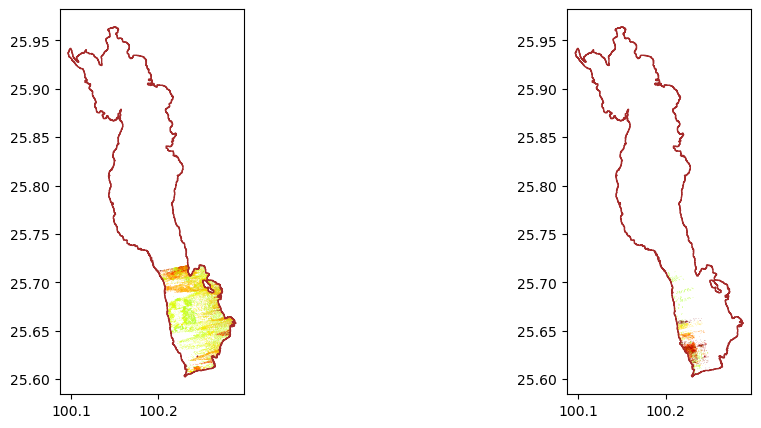

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
# ax1
scat1 = ax[0].scatter(x=pixc_nc_1.longitude, y=pixc_nc_1.latitude, c=pixc_nc_1.height,
           s=0.1, edgecolor='none', cmap='jet', clim=(1700, 2100))
lake_gpd.plot(ax=ax[0], edgecolor='Brown', facecolor='none', linewidth=1)
# ctx.add_basemap(ax[0], crs=lake_gpd.crs.to_string())
# ax2
scat2 = ax[1].scatter(x=pixc_nc_2.longitude, y=pixc_nc_2.latitude, c=pixc_nc_2.height,
            s=0.1, edgecolor='none', cmap='jet', clim=(1700, 2100))
lake_gpd.plot(ax=ax[1], edgecolor='Brown', facecolor='none', linewidth=1)
# ctx.add_basemap(ax[1], crs=lake_gpd.crs.to_string())
# fig.colorbar(scat2).set_label('height (m)')
